In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
class KNNClassifier:
    def __init__(self, k=3):
        self.k = k

    def _euclidean_dist(self, x1, x2):
        return np.sqrt(np.sum((x1 - x2) ** 2))

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
        
    def predict_one(self, x):
        distance = [self._euclidean_dist(x, x_train) for x_train in self.X_train]
        knn = np.argsort(distance)[:self.k]

        knn_classes = [self.y_train[i] for i in knn]

        majority_class = np.argmax(np.bincount(knn_classes))
        return majority_class
        
    def predict(self, X):
        y_pred = [self.predict_one(x) for x in X]
        return y_pred

In [3]:
# Data
X_train = np.array([
    [1, 2],
    [2, 3],
    [3, 3],
    [6, 5],
    [7, 7]])

y_train = np.array([0, 0, 0, 1, 1])

X_test = np.array([
    [2, 2], 
    [6, 6]]
)

In [4]:
X_train_df = pd.DataFrame(X_train, columns=['x1', 'x2'])
X_train_df['label'] = y_train

X_train_df

,x1,x2,label
0,1,2,0
1,2,3,0
2,3,3,0
3,6,5,1
4,7,7,1


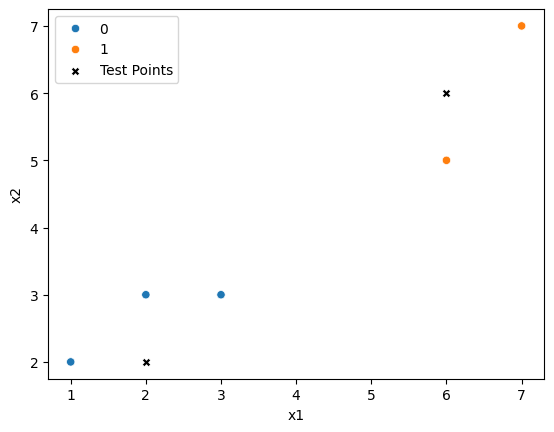

In [5]:
sns.scatterplot(
    data = X_train_df,
    x = 'x1',
    y = 'x2',
    hue = 'label'
)

X_test_df = pd.DataFrame(X_test, columns=['x1', 'x2'])

sns.scatterplot(
    data = X_test_df,
    x = 'x1',
    y = 'x2',
    color = "black",
    marker = 'X',
    label = "Test Points"
)
plt.show()

In [6]:
model = KNNClassifier()
model.fit(X_train, y_train)
y_prad = model.predict(X_test)
print(y_prad)

[np.int64(0), np.int64(1)]
